### Testing script of the CNN model
#### TODO:

+ THink of why accuracy goes down again after dropout 0.1! (might be okay due to fairly small model)
+ Why Adam and not AdamW? 
+ Create requirments file!
+ ToDo: Run the cnns on different padding (0, 1, 3) and kernel size as well (3x3, 5x5, 7x7) with Epoch 10 (so six runs) and then write down why we decided for the most part on the 3x3 and 1 (if the output serves us right)

**At the end**
+ Make it all in a script to be run from command line
+ Add argument parsing for hyperparameters


**To include in the report**
+ Trained two CNNs with difference in how they would be able to handle differently sized images. However, since the Dataloader of PyTorch doesnt really support that (except for with some tweaks that are really not necessary for this exercise, changing how the batches are passed essentially), it was decided to not analyze things like runtime and accuracy further with the second dataset. We already got an idea of the performance and will hence only use SimpleCNN for the first model now
+ Big learning out of the above: We ofc learned that Feed-Forward networks only really take fixed sized inputs, but we tried anyhow to make it work but yeah simply wasted time then haha



### Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN, SimpleAdaptiveCNN
from data.load_cifar import CIFAR10
from train import train_model
from analysis.evaluation import evaluate_model
from data.load_gtsrb import GTSRB_CLASSES, GTSRB


# https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision.transforms as transforms
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np

## CIFAR related Area

### Training Area

In [ ]:
# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(32, padding=4), # padding is ofc applied dbefore cropping randomly
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None
val_transforms = None

# Create datasets
train_dataset = CIFAR10(split="train", transform=train_transforms)
test_dataset  = CIFAR10(split="test", transform=val_transforms)

# Class names in CIFAR-10
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Using device: cpu


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/Exercise3/data/load_cifar.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")


Train samples: 50000
Test samples: 10000


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


In [ ]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2
epochs=20

model_selection = {"SimpleCNN_dropout_05": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5), 
                    "SimpleCNN_dropout_04": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.4),
                    "SimpleCNN_dropout_03": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.3), 
                    "SimpleCNN_dropout_02": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.2), 
                    "SimpleCNN_dropout_01": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.1),   
                    "SimpleCNN_dropout_00": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.0)       
                                }

for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_cifar10.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)

    del trained_model

### Show here the training and validation times of our models 
Dropout at 0.5, only things changed is augmentation on/off and the comparison between the two CNN models over number of Epochs

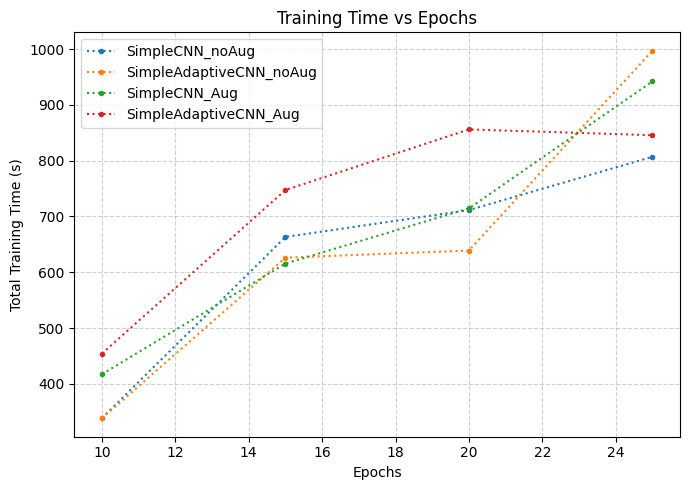

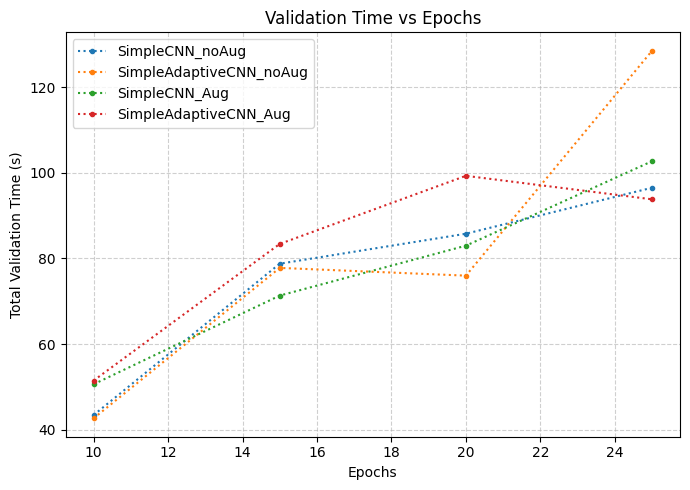

In [ ]:
train_val_times = {   
    #/cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
    "SimpleCNN_10Epochs_noAug": {
        "Total Training Time": 338.53 ,
        "Total Validation Time": 43.4 
        } ,
    "SimpleAdaptiveCNN_10Epochs_noAug":{
        "Total Training Time"  : 338.12 ,
        "Total Validation Time": 42.64
        },
    "SimpleCNN_10Epochs_Aug": {
        "Total Training Time"  : 417.16,
        "Total Validation Time": 50.60
        },
    "SimpleAdaptiveCNN_10Epochs_Aug" : {
        "Total Training Time" : 454.24,
        "Total Validation Time": 51.46,
        },

    # /cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
    "SimpleCNN_15Epochs_noAug": {
        "Total Training Time"  : 663.27,
        "Total Validation Time": 78.77
        },
    "SimpleAdaptiveCNN_15Epochs_noAug": {
        "Total Training Time"  : 626.09,
        "Total Validation Time": 77.79
        },
    "SimpleCNN_15Epochs_Aug": {
        "Total Training Time"  : 615.57,
        "Total Validation Time": 71.32
        },
    "SimpleAdaptiveCNN_15Epochs_Aug": {
        "Total Training Time"  : 747.35,
        "Total Validation Time": 83.39
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
    "SimpleCNN_20Epochs_noAug": {
        "Total Training Time"  : 711.45,
        "Total Validation Time": 85.77
        },
    "SimpleAdaptiveCNN_20Epochs_noAug": {
        "Total Training Time"  : 638.99,
        "Total Validation Time": 75.98
        },

    "SimpleCNN_20Epochs_Aug": {
        "Total Training Time"  : 714.55,
        "Total Validation Time": 82.98
        },
    "SimpleAdaptiveCNN_20Epochs_Aug": {
        "Total Training Time"  : 856.05,
        "Total Validation Time": 99.3
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twentyfive_epochs
    "SimpleCNN_25Epochs_noAug":{
        "Total Training Time"  : 807.0,
        "Total Validation Time": 96.52
    },
    "SimpleAdaptiveCNN_25Epochs_noAug": {
        "Total Training Time"  : 997.14,
        "Total Validation Time": 128.53
    },

    "SimpleCNN_25Epochs_Aug": {
        "Total Training Time"  : 942.12,
        "Total Validation Time": 102.72
        },

    "SimpleAdaptiveCNN_25Epochs_Aug": {
        "Total Training Time"  : 845.66,
        "Total Validation Time": 93.81
        }
}


# Epochs
epochs = [10, 15, 20, 25]

# Extracted data in order of epochs above
train_times = {
    "SimpleCNN_noAug": [338.53, 663.27, 711.45, 807.0],
    "SimpleAdaptiveCNN_noAug": [338.12, 626.09, 638.99, 997.14],
    "SimpleCNN_Aug": [417.16, 615.57, 714.55, 942.12],
    "SimpleAdaptiveCNN_Aug": [454.24, 747.35, 856.05, 845.66],
}

val_times = {
    "SimpleCNN_noAug": [43.4, 78.77, 85.77, 96.52],
    "SimpleAdaptiveCNN_noAug": [42.64, 77.79, 75.98, 128.53],
    "SimpleCNN_Aug": [50.60, 71.32, 82.98, 102.72],
    "SimpleAdaptiveCNN_Aug": [51.46, 83.39, 99.3, 93.81],
}

# Training time plot
plt.figure(figsize=(7, 5))
for label, values in train_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Training Time (s)")
plt.title("Training Time vs Epochs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Validation time plot
plt.figure(figsize=(7, 5))
for label, values in val_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Validation Time (s)")
plt.title("Validation Time vs Epochs")
plt.legend()
plt.grid(True,linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Show here the final validation error of the models from before

**Meaning of the suffices**

/cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
+ _wo_normalization: There we did not normalize the img in Load_Cifar with std and dev
+ v1: without data augmentation
+ v2: with data augmentation

/cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

/cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

/cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twentyfive_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

In [ ]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2

models = {
    'SimpleCNN_10Epochs_noNorm': 'Ten_Epochs/simplecnn_cifar10_wo_normalization.pth', 'SimpleAdaptiveCNN_10Epochs_noNorm': 'Ten_Epochs/simpleadaptivecnn_cifar10_wo_normalization.pth', 
    'SimpleCNN_10Epochs_noAug': 'Ten_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_10Epochs_noAug': 'Ten_Epochs/simpleadaptivecnn_cifar10_v1.pth', 
    'SimpleCNN_10Epochs_Aug': 'Ten_Epochs/simplecnn_cifar10_v2.pth', 'SimpleAdaptiveCNN_10Epochs_Aug': 'Ten_Epochs/simpleadaptivecnn_cifar10_v2.pth', 

    'SimpleCNN_15Epochs_noAug': 'Fifteen_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_15Epochs_noAug': 'Fifteen_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_15Epochs_Aug': 'Fifteen_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_15Epochs_Aug': 'Fifteen_Epochs/simpleadaptivecnn_cifar10_v1.pth', 

    'SimpleCNN_20Epochs_noAug': 'Twenty_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_20Epochs_noAug': 'Twenty_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_20Epochs_Aug': 'Twenty_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_20Epochs_Aug': 'Twenty_Epochs/simpleadaptivecnn_cifar10_v1.pth', 

    'SimpleCNN_25Epochs_noAug': 'Twentyfive_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_25Epochs_noAug': 'Twentyfive_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_25Epochs_Aug': 'Twentyfive_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_25Epochs_Aug': 'Twentyfive_Epochs/simpleadaptivecnn_cifar10_v1.pth'
    }


validation_error = {}
for key, value in models.items():
    if "SimpleCNN" in key:
        trained_model = SimpleCNN(in_channels=in_channels, 
                          num_classes=num_classes, 
                          input_size=input_size,
                          base_channels=base_channels, 
                          channel_multiplier=channel_multiplier,
                          dropout_rate=0.5)
    elif "SimpleAdaptiveCNN" in key:
        trained_model = SimpleAdaptiveCNN(in_channels=in_channels, 
                                  num_classes=num_classes, 
                                  input_size=input_size,
                                  base_channels=base_channels, 
                                  channel_multiplier=channel_multiplier,
                                  dropout_rate=0.5)
        
    filename = value
    trained_model.load_state_dict(torch.load(f"cnn_trained_models/CIFAR/{filename}"))

    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy for {key}: {correct / total:.4f}")
    validation_error[key] = correct / total

/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Final validation accuracy for SimpleCNN_10Epochs_noNorm: 0.5302
Final validation accuracy for SimpleAdaptiveCNN_10Epochs_noNorm: 0.2965
Final validation accuracy for SimpleCNN_10Epochs_noAug: 0.7710
Final validation accuracy for SimpleAdaptiveCNN_10Epochs_noAug: 0.7199
Final validation accuracy for SimpleCNN_10Epochs_Aug: 0.7587
Final validation accuracy for SimpleAdaptiveCNN_10Epochs_Aug: 0.6832
Final validation accuracy for SimpleCNN_15Epochs_noAug: 0.7693
Final validation accuracy for SimpleAdaptiveCNN_15Epochs_noAug: 0.7493
Final validation accuracy for SimpleCNN_15Epochs_Aug: 0.7845
Final validation accuracy for SimpleAdaptiveCNN_15Epochs_Aug: 0.7214
Final validation accuracy for SimpleCNN_20Epochs_noAug: 0.7741
Final validation accuracy for SimpleAdaptiveCNN_20Epochs_noAug: 0.7632
Final validation accuracy for SimpleCNN_20Epochs_Aug: 0.7992
Final validation accuracy for SimpleAdaptiveCNN_20Epochs_Aug: 0.7477
Final validation accuracy for SimpleCNN_25Epochs_noAug: 0.7732
Final val

{'SimpleCNN_10Epochs_noNorm': 0.5302, 'SimpleAdaptiveCNN_10Epochs_noNorm': 0.2965, 'SimpleCNN_10Epochs_noAug': 0.771, 'SimpleAdaptiveCNN_10Epochs_noAug': 0.7199, 'SimpleCNN_10Epochs_Aug': 0.7587, 'SimpleAdaptiveCNN_10Epochs_Aug': 0.6832, 'SimpleCNN_15Epochs_noAug': 0.7693, 'SimpleAdaptiveCNN_15Epochs_noAug': 0.7493, 'SimpleCNN_15Epochs_Aug': 0.7845, 'SimpleAdaptiveCNN_15Epochs_Aug': 0.7214, 'SimpleCNN_20Epochs_noAug': 0.7741, 'SimpleAdaptiveCNN_20Epochs_noAug': 0.7632, 'SimpleCNN_20Epochs_Aug': 0.7992, 'SimpleAdaptiveCNN_20Epochs_Aug': 0.7477, 'SimpleCNN_25Epochs_noAug': 0.7732, 'SimpleAdaptiveCNN_25Epochs_noAug': 0.7649, 'SimpleCNN_25Epochs_Aug': 0.8104, 'SimpleAdaptiveCNN_25Epochs_Aug': 0.7617}


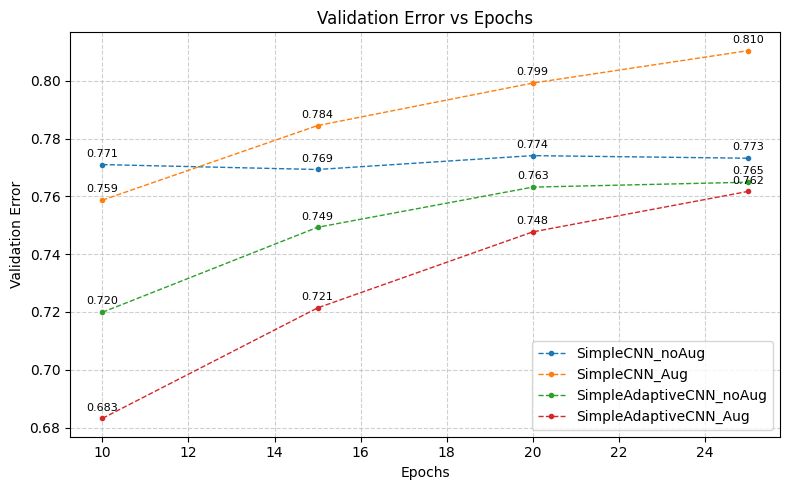

In [62]:
print(validation_error)

epochs = [10, 15, 20, 25]
data = {
    "SimpleCNN_noAug": [0.771, 0.7693, 0.7741, 0.7732],
    "SimpleCNN_Aug": [0.7587, 0.7845, 0.7992, 0.8104],
    "SimpleAdaptiveCNN_noAug": [0.7199, 0.7493, 0.7632, 0.7649],
    "SimpleAdaptiveCNN_Aug": [0.6832, 0.7214, 0.7477, 0.7617],
}

plt.figure(figsize=(8, 5))

for label, values in data.items():
    plt.plot(epochs, values, marker=".", linestyle="--", linewidth=1, label=label)

    for x, y in zip(epochs, values): 
        plt.text(
            x, 
            y + 0.002, 
            f"{y:.3f}",
            ha="center", va="bottom", fontsize=8)
        
plt.xlabel("Epochs")
plt.ylabel("Validation Error")
plt.title("Validation Error vs Epochs")
plt.legend()
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Plotting here the impact of dropout

Dropout tested: [0.5, 0.4, 0.3, 0.2, 0.1, 0.0]. Other "variables" set: Augmentation on and 20 Epochs

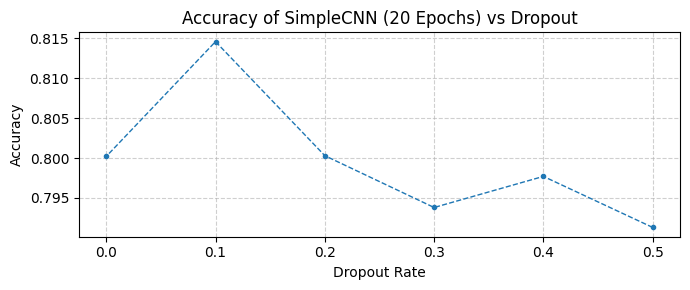

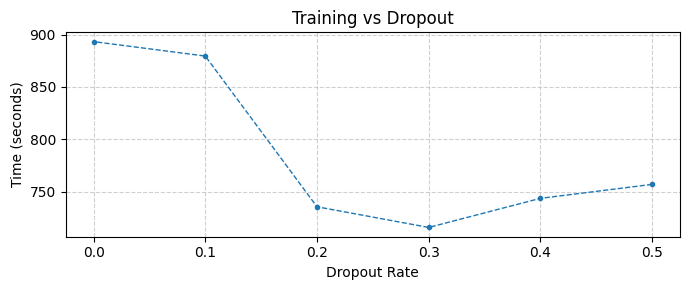

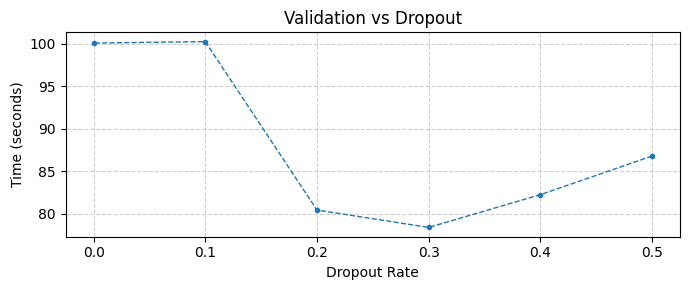

In [ ]:
dropout_model_accuracy = {
    "SimpleCNN_dropout_05": 0.7913, 
    "SimpleCNN_dropout_04": 0.7977, 
    "SimpleCNN_dropout_03": 0.7938,       
    "SimpleCNN_dropout_02": 0.8003,
    "SimpleCNN_dropout_01": 0.8146,   
    "SimpleCNN_dropout_00": 0.8002
    }

# (train, val)        
dropout_model_training_validation_time = {               
    "SimpleCNN_dropout_05": (757.07, 86.77), 
    "SimpleCNN_dropout_04": (743.74, 82.23), 
    "SimpleCNN_dropout_03": (716.00, 78.37),       
    "SimpleCNN_dropout_02": (735.72, 80.42),  
    "SimpleCNN_dropout_01": (879.49, 100.24),
    "SimpleCNN_dropout_00": (893.26, 100.07)
    }


# Extract dropout values from the name
dropout_values = np.array([int(k[-2:]) / 10 for k in dropout_model_accuracy.keys()])
accuracies = np.array(list(dropout_model_accuracy.values()))

# Accuracy Plot
plt.figure(figsize=(7, 3))
plt.plot(dropout_values, accuracies, marker=".", linestyle="--", linewidth=1)

plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy")
plt.title("Accuracy of SimpleCNN (20 Epochs) vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

# Training & Validation Time Plot
train_times = [v[0] for v in dropout_model_training_validation_time.values()]
val_times = [v[1] for v in dropout_model_training_validation_time.values()]

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, train_times, marker=".", linestyle="--", linewidth=1, label="Training Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Training vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, val_times, marker=".", linestyle="--", linewidth=1, label="Validation Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Validation vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

## GTSRB related Area

### Training Area

In [4]:
# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(64, padding=4), # padding is ofc applied dbefore cropping randomly
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None 
val_transforms = None

training_path = "../data/GTSRB/Final_Training/Images"
testing_path = "../data/GTSRB/Final_Test/Images"

# Create datasets
train_dataset = GTSRB(base_path=training_path, split="train", transform=train_transforms)
test_dataset  = GTSRB(base_path=testing_path, split="test", transform=None)

# Class names in GTSRB
class_names = list(GTSRB_CLASSES.values())

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

#Using device: cpu
#Loading GTSRB (train) from ../data/GTSRB/Final_Training/Images...
#Loading GTSRB (test) from ../data/GTSRB/Final_Test/Images...
#Train samples: 39209
#Test samples: 12630
#Image batch shape: torch.Size([128, 3, 64, 64])
#Label batch shape: torch.Size([128])
#Image dtype: torch.float32
#Label dtype: torch.int64

Using device: cpu
Loading GTSRB (train) from ../data/GTSRB/Final_Training/Images...
Loading GTSRB (test) from ../data/GTSRB/Final_Test/Images...
Train samples: 39209
Test samples: 12630


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 64, 64])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


Training model: SimpleCNN_Epoch_10
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/10


Train Loss: 2.0463 | Train Acc: 0.3881
Train Time: 87.49s
Val   Loss: 0.9965 | Val   Acc: 0.6613
Val   Time: 13.97s

Epoch 2/10


Train Loss: 0.8908 | Train Acc: 0.6999
Train Time: 89.88s
Val   Loss: 0.5032 | Val   Acc: 0.8378
Val   Time: 14.19s

Epoch 3/10


Train Loss: 0.5317 | Train Acc: 0.8196
Train Time: 98.13s
Val   Loss: 0.3234 | Val   Acc: 0.8907
Val   Time: 16.75s

Epoch 4/10


Train Loss: 0.3614 | Train Acc: 0.8776
Train Time: 86.63s
Val   Loss: 0.2933 | Val   Acc: 0.8998
Val   Time: 12.78s

Epoch 5/10


...

Train Loss: 0.2189 | Train Acc: 0.9274
Train Time: 85.66s
Val   Loss: 0.2346 | Val   Acc: 0.9318
Val   Time: 12.90s

Epoch 7/10


Train Loss: 0.1831 | Train Acc: 0.9394
Train Time: 87.01s
Val   Loss: 0.1889 | Val   Acc: 0.9405
Val   Time: 13.37s

Epoch 8/10


Train Loss: 0.1606 | Train Acc: 0.9467
Train Time: 90.12s
Val   Loss: 0.1951 | Val   Acc: 0.9408
Val   Time: 13.39s

Epoch 9/10


Train Loss: 0.1427 | Train Acc: 0.9518
Train Time: 92.23s
Val   Loss: 0.1885 | Val   Acc: 0.9418
Val   Time: 14.07s

Epoch 10/10


Train Loss: 0.1356 | Train Acc: 0.9548
Train Time: 97.27s
Val   Loss: 0.1793 | Val   Acc: 0.9477
Val   Time: 13.59s

Total Training Time  : 899.77s
Total Validation Time: 137.78s


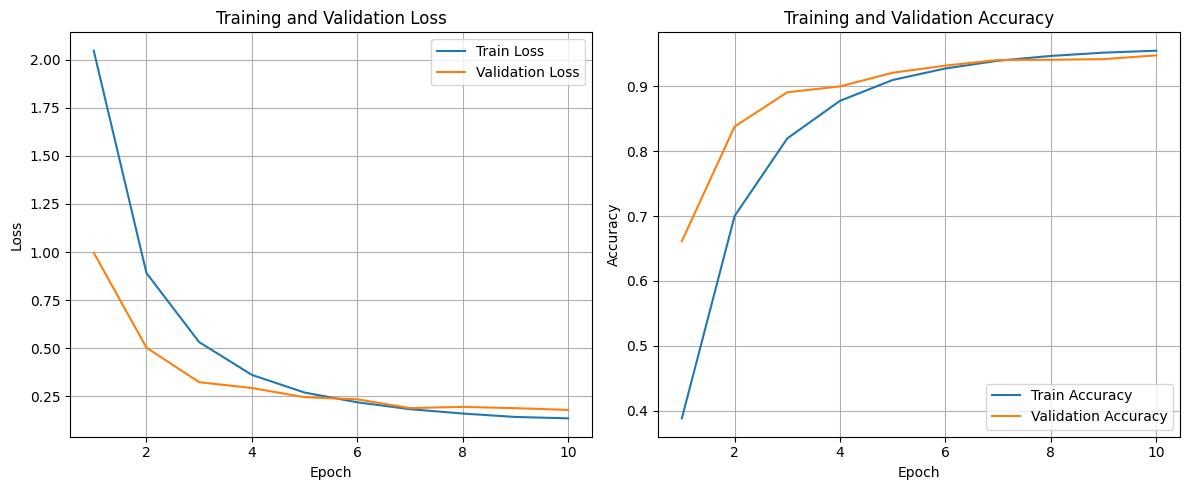

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_epoch_10_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9477

Model Evaluation
----------------
Overall accuracy: 0.9477

Per-class accuracy:
  Speed 20: 0.733
  Speed 30: 0.990
  Speed 50: 0.989
  Speed 60: 0.878
  Speed 70: 0.986
  Speed 80: 0.921
End Speed 80: 0.907
 Speed 100: 0.933
 Speed 120: 0.987
No passing: 0.998
No passing >3.5t: 0.983
Right-of-way: 0.974
Priority road: 0.958
     Yield: 0.992
      Stop: 1.000
No vehicles: 0.986
Veh >3.5t prohib: 1.000
  No entry: 0.975
General caution: 0.949
Curve left: 1.000
Curve right: 0.700
Double curve: 0.856
Bumpy road: 0.833
  Slippery: 0.913
Narrows right: 0.989
 Road work: 0.973
Traffic signals: 0.994
Pedestrians: 0.500
  Children: 0.980
  Bicycles: 0.989
  Ice/Snow: 0.680
Wild animals: 0.959
End limits: 1.000
Turn right: 0.905
 Turn left: 0.733
Ahead only: 0.997
Straight/Right: 0.675
Straight/Left: 0.700
Keep right: 0.939

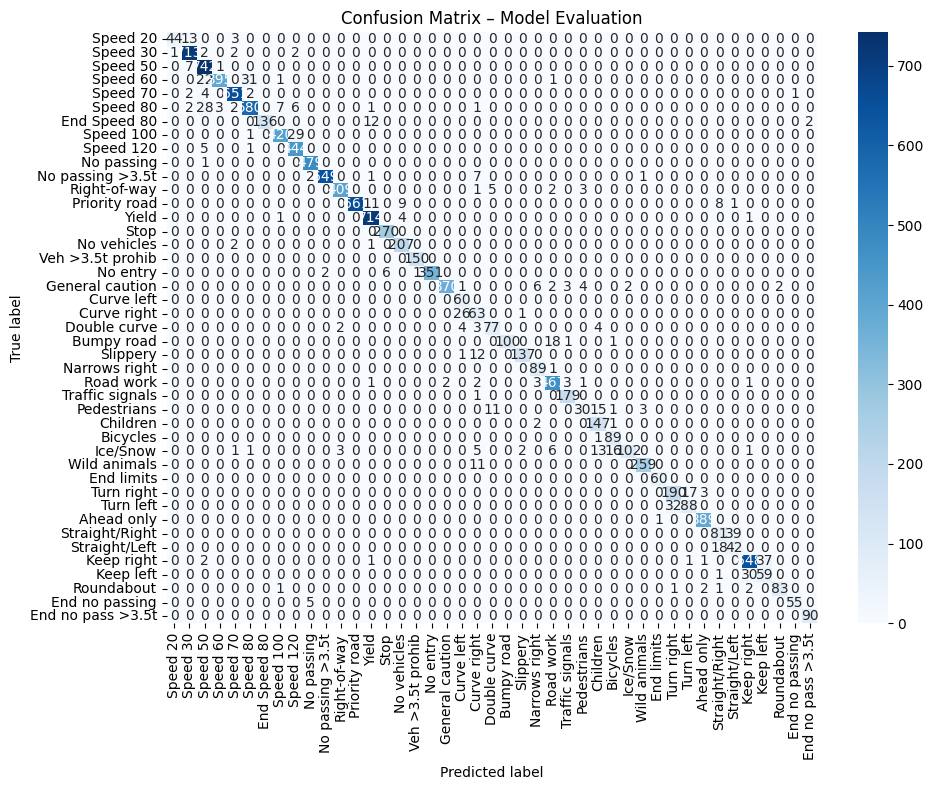

Training model: SimpleCNN_Epoch_15
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/15


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 2.0652 | Train Acc: 0.3802
Train Time: 101.37s
Val   Loss: 1.0632 | Val   Acc: 0.6254
Val   Time: 19.05s

Epoch 2/15


Train Loss: 0.9225 | Train Acc: 0.6884
Train Time: 103.68s
Val   Loss: 0.5305 | Val   Acc: 0.8296
Val   Time: 16.71s

Epoch 3/15


Train Loss: 0.5222 | Train Acc: 0.8259
Train Time: 103.07s
Val   Loss: 0.3177 | Val   Acc: 0.8987
Val   Time: 16.16s

Epoch 4/15


...

Train Loss: 0.1141 | Train Acc: 0.9619
Train Time: 106.58s
Val   Loss: 0.1928 | Val   Acc: 0.9540
Val   Time: 19.21s

Epoch 12/15


Train Loss: 0.1035 | Train Acc: 0.9659
Train Time: 109.03s
Val   Loss: 0.1863 | Val   Acc: 0.9567
Val   Time: 15.66s

Epoch 13/15


Train Loss: 0.0986 | Train Acc: 0.9673
Train Time: 97.23s
Val   Loss: 0.2250 | Val   Acc: 0.9462
Val   Time: 18.56s

Epoch 14/15


Train Loss: 0.0922 | Train Acc: 0.9694
Train Time: 102.16s
Val   Loss: 0.1806 | Val   Acc: 0.9576
Val   Time: 15.26s

Epoch 15/15


Train Loss: 0.0850 | Train Acc: 0.9710
Train Time: 112.89s
Val   Loss: 0.1771 | Val   Acc: 0.9599
Val   Time: 19.96s

Total Training Time  : 1547.42s
Total Validation Time: 248.24s


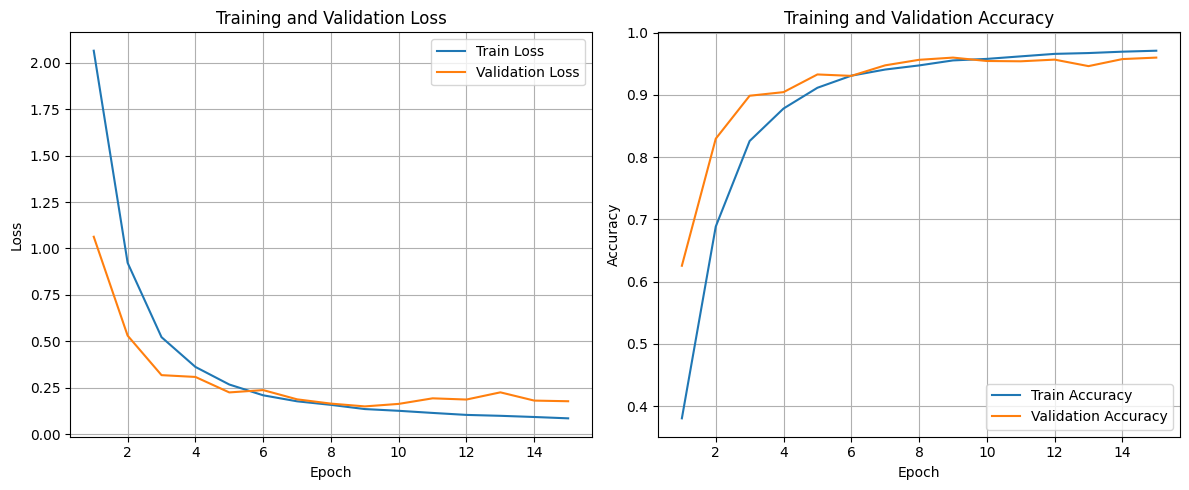

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_epoch_15_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9599

Model Evaluation
----------------
Overall accuracy: 0.9599

Per-class accuracy:
  Speed 20: 1.000
  Speed 30: 0.992
  Speed 50: 0.988
  Speed 60: 0.976
  Speed 70: 0.964
  Speed 80: 0.979
End Speed 80: 0.853
 Speed 100: 0.973
 Speed 120: 0.998
No passing: 1.000
No passing >3.5t: 0.997
Right-of-way: 0.998
Priority road: 0.974
     Yield: 0.996
      Stop: 1.000
No vehicles: 0.976
Veh >3.5t prohib: 1.000
  No entry: 0.922
General caution: 0.915
Curve left: 1.000
Curve right: 0.556
Double curve: 0.867
Bumpy road: 0.767
  Slippery: 0.927
Narrows right: 0.956
 Road work: 0.996
Traffic signals: 0.994
Pedestrians: 0.500
  Children: 0.973
  Bicycles: 0.989
  Ice/Snow: 0.667
Wild animals: 0.985
End limits: 1.000
Turn right: 0.938
 Turn left: 0.933
Ahead only: 0.979
Straight/Right: 0.958
Straight/Left: 0.383
Keep right: 0.977

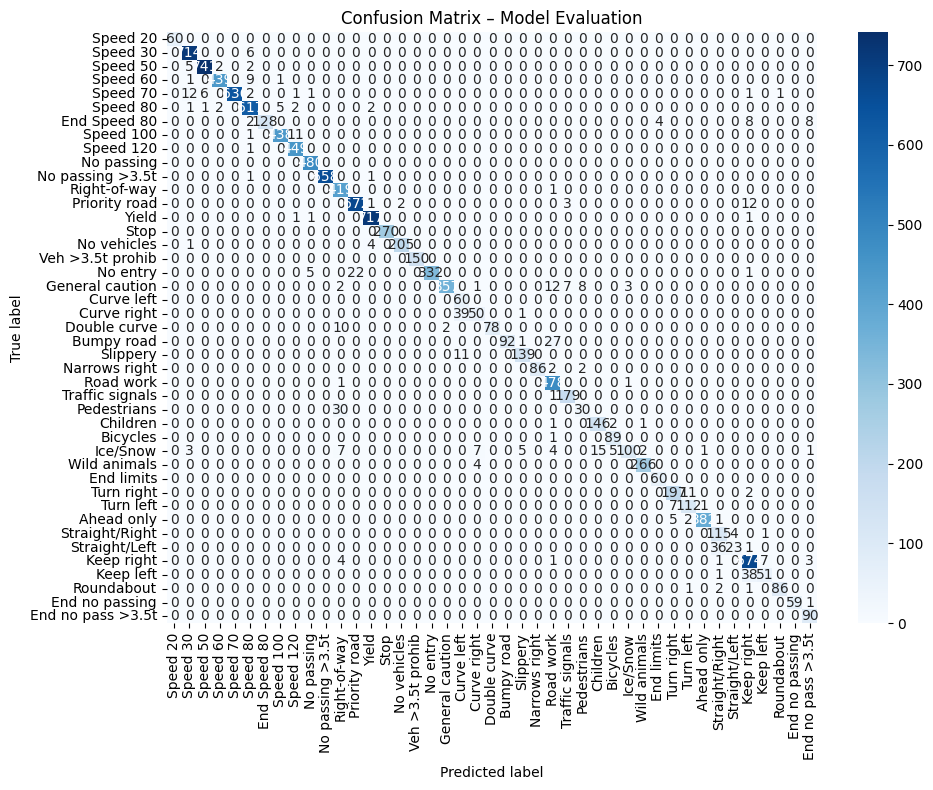

Training model: SimpleCNN_Epoch_20
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 2.0356 | Train Acc: 0.3950
Train Time: 118.62s
Val   Loss: 1.0480 | Val   Acc: 0.6538
Val   Time: 18.01s

Epoch 2/20


Train Loss: 0.9026 | Train Acc: 0.6978
Train Time: 113.26s
Val   Loss: 0.5063 | Val   Acc: 0.8318
Val   Time: 16.23s

Epoch 3/20


Train Loss: 0.5539 | Train Acc: 0.8136
Train Time: 110.11s
Val   Loss: 0.3896 | Val   Acc: 0.8683
Val   Time: 16.46s

Epoch 4/20


...

Train Loss: 0.0872 | Train Acc: 0.9703
Train Time: 98.40s
Val   Loss: 0.1450 | Val   Acc: 0.9565
Val   Time: 15.32s

Epoch 17/20


Train Loss: 0.0863 | Train Acc: 0.9712
Train Time: 101.35s
Val   Loss: 0.1563 | Val   Acc: 0.9568
Val   Time: 15.42s

Epoch 18/20


Train Loss: 0.0806 | Train Acc: 0.9730
Train Time: 99.89s
Val   Loss: 0.1449 | Val   Acc: 0.9557
Val   Time: 15.21s

Epoch 19/20


Train Loss: 0.0743 | Train Acc: 0.9755
Train Time: 96.53s
Val   Loss: 0.1674 | Val   Acc: 0.9555
Val   Time: 14.30s

Epoch 20/20


Train Loss: 0.0767 | Train Acc: 0.9760
Train Time: 93.49s
Val   Loss: 0.1821 | Val   Acc: 0.9537
Val   Time: 14.20s

Total Training Time  : 2102.18s
Total Validation Time: 317.56s


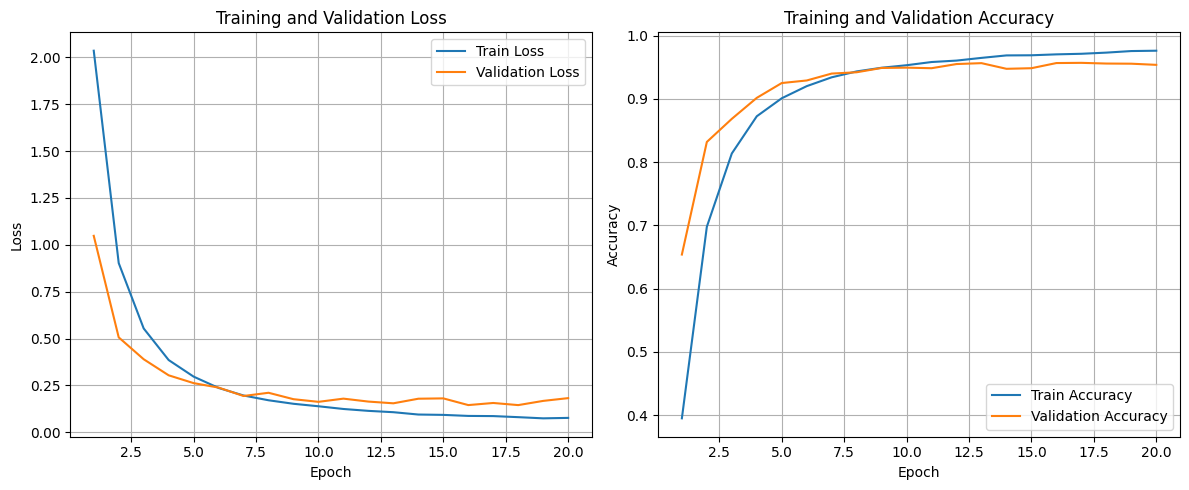

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_epoch_20_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9537

Model Evaluation
----------------
Overall accuracy: 0.9537

Per-class accuracy:
  Speed 20: 0.933
  Speed 30: 0.990
  Speed 50: 0.989
  Speed 60: 0.960
  Speed 70: 0.982
  Speed 80: 0.989
End Speed 80: 0.867
 Speed 100: 0.967
 Speed 120: 0.984
No passing: 1.000
No passing >3.5t: 0.989
Right-of-way: 0.990
Priority road: 0.977
     Yield: 0.999
      Stop: 1.000
No vehicles: 0.995
Veh >3.5t prohib: 1.000
  No entry: 0.989
General caution: 0.985
Curve left: 0.317
Curve right: 0.944
Double curve: 1.000
Bumpy road: 0.775
  Slippery: 0.920
Narrows right: 0.978
 Road work: 0.973
Traffic signals: 1.000
Pedestrians: 0.500
  Children: 0.987
  Bicycles: 1.000
  Ice/Snow: 0.773
Wild animals: 0.978
End limits: 1.000
Turn right: 0.605
 Turn left: 0.992
Ahead only: 0.962
Straight/Right: 0.633
Straight/Left: 0.117
Keep right: 0.988

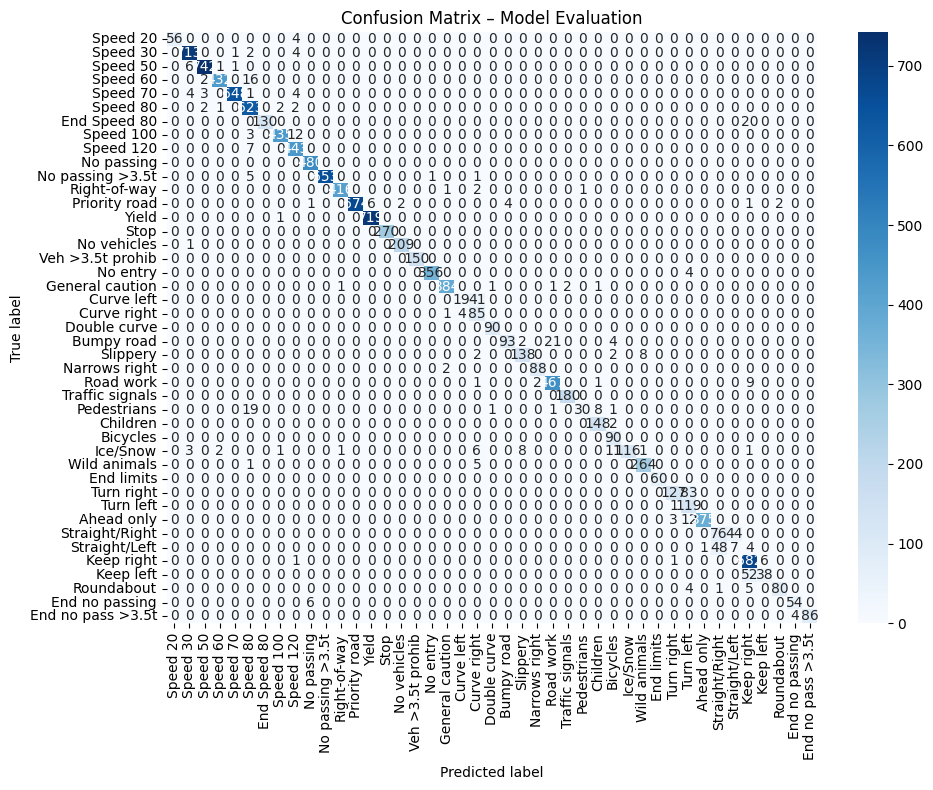

Training model: SimpleCNN_Epoch_25
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/25


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 2.0717 | Train Acc: 0.3801
Train Time: 93.17s
Val   Loss: 1.1149 | Val   Acc: 0.6118
Val   Time: 14.08s

Epoch 2/25


Train Loss: 0.9871 | Train Acc: 0.6636
Train Time: 92.89s
Val   Loss: 0.5799 | Val   Acc: 0.8022
Val   Time: 14.01s

Epoch 3/25


Train Loss: 0.5760 | Train Acc: 0.8026
Train Time: 92.42s
Val   Loss: 0.3290 | Val   Acc: 0.8915
Val   Time: 14.53s

Epoch 4/25


...

Train Loss: 0.0691 | Train Acc: 0.9778
Train Time: 92.40s
Val   Loss: 0.1771 | Val   Acc: 0.9554
Val   Time: 13.89s

Epoch 22/25


Train Loss: 0.0693 | Train Acc: 0.9775
Train Time: 92.21s
Val   Loss: 0.1815 | Val   Acc: 0.9576
Val   Time: 14.02s

Epoch 23/25


Train Loss: 0.0665 | Train Acc: 0.9781
Train Time: 92.35s
Val   Loss: 0.1708 | Val   Acc: 0.9566
Val   Time: 13.93s

Epoch 24/25


Train Loss: 0.0610 | Train Acc: 0.9797
Train Time: 92.06s
Val   Loss: 0.2032 | Val   Acc: 0.9574
Val   Time: 13.76s

Epoch 25/25


Train Loss: 0.0583 | Train Acc: 0.9811
Train Time: 94.67s
Val   Loss: 0.1493 | Val   Acc: 0.9625
Val   Time: 14.36s

Total Training Time  : 2324.52s
Total Validation Time: 350.46s


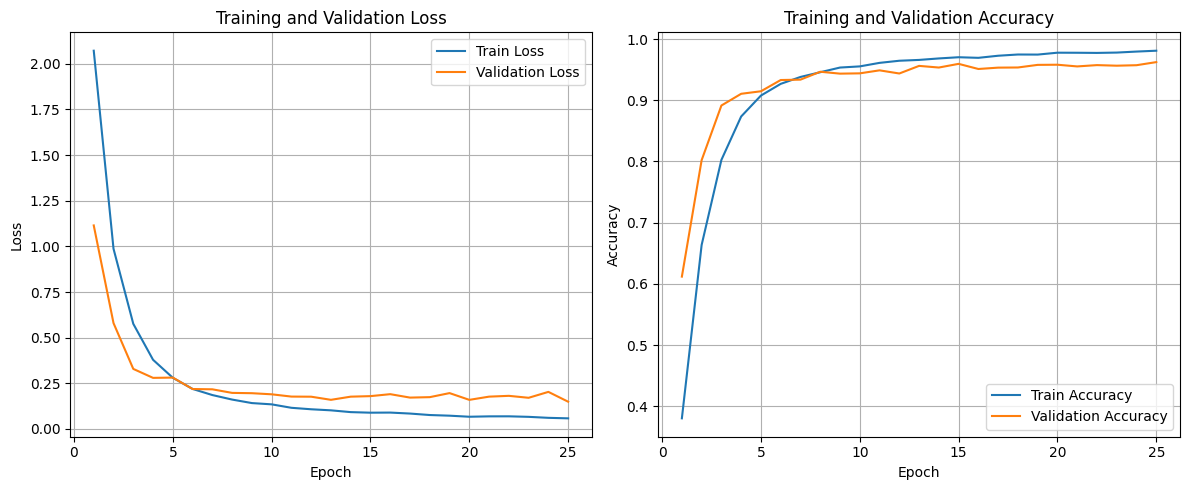

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_epoch_25_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9625

Model Evaluation
----------------
Overall accuracy: 0.9625

Per-class accuracy:
  Speed 20: 0.983
  Speed 30: 0.997
  Speed 50: 0.993
  Speed 60: 0.976
  Speed 70: 0.979
  Speed 80: 0.940
End Speed 80: 0.907
 Speed 100: 0.960
 Speed 120: 0.947
No passing: 1.000
No passing >3.5t: 0.994
Right-of-way: 0.998
Priority road: 0.965
     Yield: 0.997
      Stop: 1.000
No vehicles: 0.986
Veh >3.5t prohib: 1.000
  No entry: 0.992
General caution: 0.962
Curve left: 0.883
Curve right: 0.978
Double curve: 1.000
Bumpy road: 0.750
  Slippery: 0.967
Narrows right: 0.989
 Road work: 0.981
Traffic signals: 0.989
Pedestrians: 0.617
  Children: 1.000
  Bicycles: 0.989
  Ice/Snow: 0.753
Wild animals: 0.974
End limits: 1.000
Turn right: 0.833
 Turn left: 0.975
Ahead only: 0.985
Straight/Right: 0.933
Straight/Left: 0.167
Keep right: 0.978

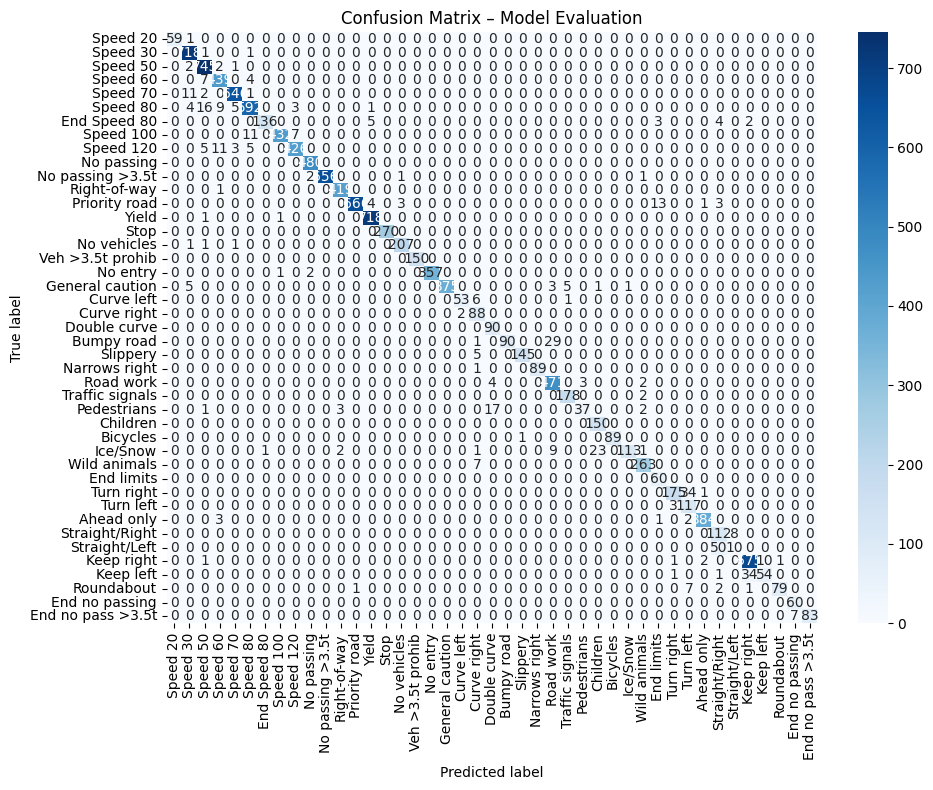

In [5]:
in_channels = 3
num_classes = len(GTSRB_CLASSES)
input_size = 64
base_channels = 32
channel_multiplier = 2
epochs=5

model_selection = { "SimpleCNN_Epoch_10": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5),
                    "SimpleCNN_Epoch_15": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5), 
                    "SimpleCNN_Epoch_20": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5), 
                    "SimpleCNN_Epoch_25": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5)}
iteration = 2
for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs*iteration
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_gtsrb.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)
    iteration += 1
    del trained_model

### Analysis Area

#### Epoch Analysis

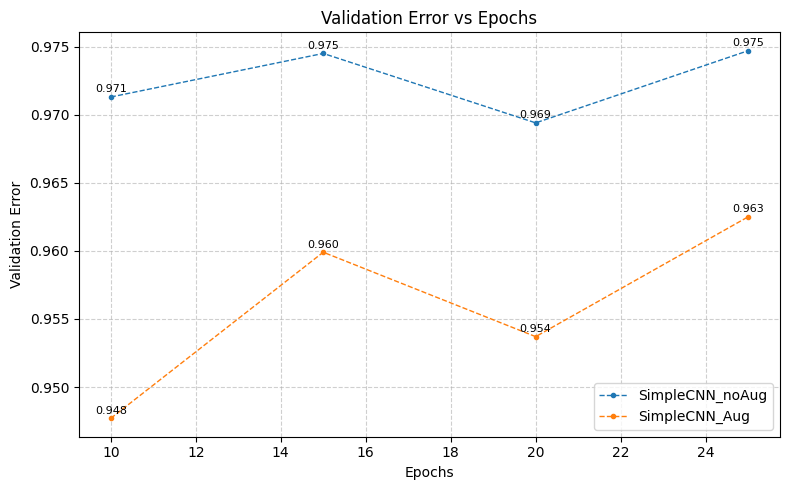

In [7]:
# TODO: Ammend the suffixes in the respective folder properly to make sense!


epochs = [10, 15, 20, 25] 
data = {
    # [0.9612, 0.9713, 0.9745, 0.9694, 0.9747],
    "SimpleCNN_noAug": [0.9713, 0.9745, 0.9694, 0.9747],
    "SimpleCNN_Aug": [0.9477, 0.9599, 0.9537, 0.9625]
}

plt.figure(figsize=(8, 5))

for label, values in data.items():
    plt.plot(epochs, values, marker=".", linestyle="--", linewidth=1, label=label)

    for x, y in zip(epochs, values): 
        plt.text(
            x, 
            y + 0.0002, 
            f"{y:.3f}",
            ha="center", va="bottom", fontsize=8)
        
plt.xlabel("Epochs")
plt.ylabel("Validation Error")
plt.title("Validation Error vs Epochs")
plt.legend()
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


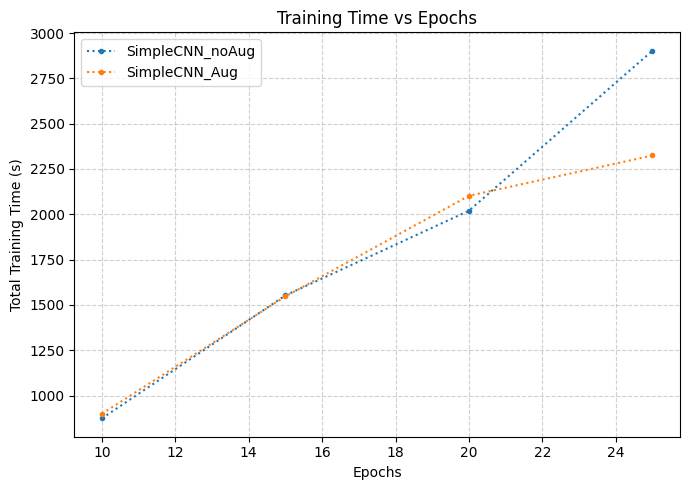

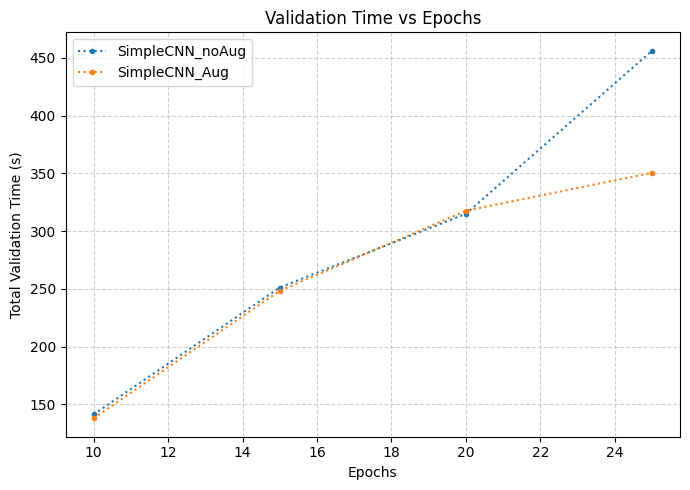

In [9]:
# Epochs
epochs = [10, 15, 20, 25] # potentially remove 5 just to be in line with the other analysis

# Extracted data in order of epochs above
train_times = {
                    # [471.32, 874.48, 1552.71, 2019.76, 2902.53],
    "SimpleCNN_noAug": [ 874.48, 1552.71, 2019.76, 2902.53],
    "SimpleCNN_Aug": [899.77, 1547.42, 2102.18, 2324.52]
}

val_times = {
                    # [73.79, 141.15, 251.09, 314.96, 456.18],
    "SimpleCNN_noAug": [141.15, 251.09, 314.96, 456.18],
    "SimpleCNN_Aug": [137.78, 248.24, 317.56, 350.46]
}

# Training time plot
plt.figure(figsize=(7, 5))
for label, values in train_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Training Time (s)")
plt.title("Training Time vs Epochs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Validation time plot
plt.figure(figsize=(7, 5))
for label, values in val_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Validation Time (s)")
plt.title("Validation Time vs Epochs")
plt.legend()
plt.grid(True,linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()